Paraller Workflow: UPSC Essay Evaluation

<pre>
                     Input (Essay)
                           |
   +-----------------------+---------------+
   |                       |               |
Clarity of Thoughts  Depth of Analysis  Language
   |                       |               |
   +-----------------------+---------------+
                           |
                     Final Evaluation
                           |
                        Output
</pre>


Here, Essay will be provided as input.
Essay will be evaluated by three parameters Clarity of Thoughts, Depth of Analysis and Language
Each parameter will provide Short summary and score (0-10)
Final evaluation node will provide a summary of all short summaries from node and will calculate the average of all scores.
And will print the following output

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator
load_dotenv()

True

In [2]:
# model = ChatGoogleGenerativeAI(model="gemini-2.5-pro")
model = ChatOpenAI(model="gpt-4.1")

In [3]:
class Evaluation(BaseModel):
    feedback:str = Field(description="Provide a short 100 words feddback for the essay")
    score:int =Field(description="Out of 10",gt=0,le=10)

In [4]:
structured_model = model.with_structured_output(Evaluation)

In [5]:
class UPSC(TypedDict):
    essay: str
    cot_feedback : str
    doa_feedback : str
    language_feedback : str
    individual_score : Annotated[list[int], operator.add]
    overall_feedback : str
    overall_score : float

In [6]:
def clarity_of_thoughts(state:UPSC):
    
    prompt = f"Evaluate the essay {state['essay']} and provide feedback based on clarity of thought and score between 0-10"

    output = structured_model.invoke(prompt)

    return {'cot_feedback': output.feedback, 'individual_score':[int(output.score)]}

In [7]:
def depth_of_analysis(state:UPSC):
    
    prompt = f"Evaluate the essay {state['essay']} and provide feedback based on depth of analysis and score between 0-10"

    output = structured_model.invoke(prompt)

    return {'doa_feedback': output.feedback, 'individual_score':[int(output.score)]}

In [8]:
def language(state:UPSC):
    
    prompt = f"Evaluate the essay {state['essay']} and provide feedback based on language and score between 0-10"

    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_score':[int(output.score)]}

In [9]:
def final_evaluation(state:UPSC):
    
    prompt = f"""Evaluate the feedbacks of essay and provide me with 100 words overall feedback Clarity of Thoughts feedback :{state['cot_feedback']} 
                                                        Depth of analysis feedback: {state['doa_feedback']}
                                                        langauge feedback : {state['language_feedback']}"""

    output = model.invoke(prompt).content

    avg_score = sum(state['individual_score'])/len(state['individual_score'])

    return {'overall_feedback': output, 'overall_score':avg_score}

In [10]:
graph = StateGraph(UPSC)

In [11]:
graph.add_node('clarity_of_thoughts',clarity_of_thoughts)
graph.add_node('depth_of_analysis',depth_of_analysis)
graph.add_node('language',language)
graph.add_node('final_evaluation',final_evaluation)

In [12]:
graph.add_edge(START,"clarity_of_thoughts")
graph.add_edge(START,"depth_of_analysis")
graph.add_edge(START,"language")

graph.add_edge('clarity_of_thoughts',"final_evaluation")
graph.add_edge('depth_of_analysis',"final_evaluation")
graph.add_edge('language',"final_evaluation")

graph.add_edge('final_evaluation',END)

workflow = graph.compile()

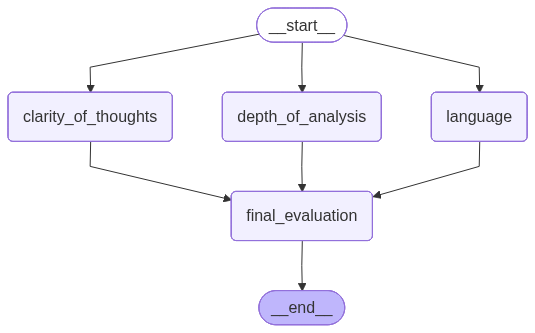

In [13]:
workflow

In [14]:
essay = """AI Won't Replace You, But a Developer Using AI Will
          The fear is palpable in every tech forum: will AI make developers obsolete? The short answer is no. But the real answer is more critical: AI won't replace you, but a developer who masters AI tools certainly will.
          Think of AI not as a rival, but as the most powerful co-pilot you’ve ever had. Tools like GitHub Copilot are already transforming workflows, handling the repetitive drudgery of boilerplate code, unit tests, and debugging suggestions. This doesn’t eliminate the developer; it elevates them. By offloading tedious tasks, AI frees you to focus on what truly matters: elegant system architecture, creative problem-solving, and building innovative features.
          The essential skill is no longer just writing code, but effectively directing an AI to write it with you. Learning to craft the right prompts is the new debugging. The developers who embrace this symbiotic relationship will become faster, smarter, and more valuable than ever. The future isn't about man versus machine; it's about the developer *with* the machine. Don’t get left behind.
        """

In [15]:
workflow.invoke({'essay':essay})

{'essay': "AI Won't Replace You, But a Developer Using AI Will\n          The fear is palpable in every tech forum: will AI make developers obsolete? The short answer is no. But the real answer is more critical: AI won't replace you, but a developer who masters AI tools certainly will.\n          Think of AI not as a rival, but as the most powerful co-pilot you’ve ever had. Tools like GitHub Copilot are already transforming workflows, handling the repetitive drudgery of boilerplate code, unit tests, and debugging suggestions. This doesn’t eliminate the developer; it elevates them. By offloading tedious tasks, AI frees you to focus on what truly matters: elegant system architecture, creative problem-solving, and building innovative features.\n          The essential skill is no longer just writing code, but effectively directing an AI to write it with you. Learning to craft the right prompts is the new debugging. The developers who embrace this symbiotic relationship will become faster,